# TPI 1: Adquisición y Análisis Lingüístico de Medios

**Modalidad:** Trabajo Práctico Individual (calificación numérica de 0 a 10).

**Fecha de entrega y exposición:** Jueves 16 de abril. Se realizará de manera expositiva en remoto frente a todo el grupo de estudiantes (aproximadamente 10 minutos por presentación) para que entre quienes participan veamos posibles soluciones.

**Duración estimada de codificación:** 2 horas

**Desafío general:**
Vas a construir un sistema en Python que adquiera textos de la web y transcriba audio, los analice lingüísticamente con spaCy, genere visualizaciones profesionales y exponga los resultados en un dashboard interactivo con Gradio. Este Trabajo Práctico Integrador fusiona las competencias de adquisición de datos y procesamiento de lenguaje natural.

**Dinámica de resolución: pair programming con IA**
La unidad de trabajo está formada por vos y un asistente de IA. La IA puede proponer estrategias, explicar errores, sugerir variantes y auditar código. No reemplaza tu pensamiento ni tu criterio. Toda decisión final, toda justificación y toda versión entregada tienen que estar bajo tu responsabilidad.

---

### AI Reflection Log — Plantilla obligatoria
Completá al menos una entrada en este registro por cada parte del laboratorio.

| Parte | Objetivo de la consulta | Prompt o pedido a la IA | Qué responidó (resumen) | Qué conservaste y por qué | Qué descartaste y por qué | Qué aprendiste |
|---|---|---|---|---|---|---|
| **Parte 1** |Definir una estrategia para lidiar con las diferencias de formato |Que estrategias podemos tomar para trabajar con las diferencias de formato en un DataFrame |Normalización de Corpus, limpieza de stopwords orales, tener una columna con texto crudo y una con texto limpio |Estandarización por Esquema Común,consiste en definir un molde único |Enriquecimiento de Metadatos,Consiste en mantener las columnas comunes, pero agregar etiquetas que identifiquen el "grado de formalidad" del texto.(complejo) |Normalizar columnas de distintos origenes |
| **Parte 2** |como generar JSON |necesito generar el archivo JSON a partir de paginas web |Para generar un archivo JSON a partir de páginas web, el flujo de trabajo estándar en Data Science es: Requests (para descargar) + BeautifulSoup (para extraer) + JSON library (para guardar) |El Codigo para crear el objeto del artículo y guardarlo un como JSON |todo el resto porque el scraping  de paginas web ya lo tenia hecho |como dar formato y guardar un archvo JSON |
| **Parte 3** | Análisis Lingüístico con spaCy|criterios para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' |Entidades de Persona (PER)  Individuos reales o ficticios, Entidades de Organización (ORG) Instituciones, empresas, organismos gubernamentales, Entidades de Ubicación (LOC / GPE) Espacios geográficos definidos, estructuras políticas territoriales y puntos de referencia físicos |Todo lo necesito para el informe |nada |repase informacion que genera spaSy |
| **Parte 4** | | | | | | |
| **Parte 5** | | | | | | |
| **Parte 6** | | | | | | |

In [46]:
import spacy
import pandas as pd
import trafilatura
import whisper
import json
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from collections import Counter
from wordcloud import WordCloud
import os
import shutil
import time
import stopwords_es as mis_stopwords
import re
import unicodedata
import yt_dlp


import requests
from bs4 import BeautifulSoup
from requests.exceptions import HTTPError

print("Librerías importadas correctamente.")

def preparar_ffmpeg() -> tuple[str, str, str]:
    ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
    if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
        raise FileNotFoundError(
            "No se encontro `ffmpeg` en PATH ni mediante la variable de entorno `FFMPEG_PATH`. "
            "Instala FFmpeg a nivel sistema y reinicia el kernel de Jupyter. "
            "En Windows podes usar: `choco install ffmpeg` o `winget install Gyan.FFmpeg`."
        )

    ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
    candidatos_ffprobe = [
        os.environ.get("FFPROBE_PATH"),
        shutil.which("ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe"),
        os.path.join(ffmpeg_dir, "ffprobe.exe"),
    ]
    ruta_ffprobe = next((ruta for ruta in candidatos_ffprobe if ruta and os.path.exists(ruta)), None)
    if ruta_ffprobe is None:
        raise FileNotFoundError("Se encontro `ffmpeg` pero no `ffprobe` en PATH ni en la misma carpeta.")

    if ffmpeg_dir not in os.environ.get("PATH", ""):
        os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    return ruta_ffmpeg, ffmpeg_dir, ruta_ffprobe

mi_lista = mis_stopwords.stopwords_es

from nltk.corpus import stopwords
sw_es = stopwords.words('spanish') # Esto devuelve la LISTA
def limpiar_texto_tp(texto, stopwords_adicionales=None):
    if not texto or not isinstance(texto, str):
        return ""

    # Convertir a minúsculas
    texto = texto.lower()

    # Eliminar acentos (opcional, pero útil para normalizar)
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto)
                  if unicodedata.category(c) != 'Mn')

    # Eliminar caracteres especiales y números (dejamos solo letras y espacios)
    texto = re.sub(r'[^a-zñ\s]', ' ', texto)

    # Definir muletillas comunes de podcasts
    muletillas = {
        'eh', 'ehm', 'este', 'estee', 'o sea', 'digamos', 'viste', 'nada', 
        'tipo', 'claro', 'bueno', 'entonces', 'como que', 'me explico', 'no'
    }

    # Combinar tus sw_es con las muletillas
    palabras_a_eliminar = set(sw_es).union(mi_lista).union(muletillas)
    if stopwords_adicionales:
        palabras_a_eliminar = palabras_a_eliminar.union(set(stopwords_adicionales))

    # Limpiar el texto palabra por palabra
    palabras = texto.split()
    palabras_limpias = [p for p in palabras if p not in palabras_a_eliminar and len(p) > 2]

    # unir y limpiar espacios extra
    return " ".join(palabras_limpias).strip()


Librerías importadas correctamente.


## Parte 1: Adquisición Multimodal del Corpus

**Objetivo:** Construir funciones que permitan alimentar el pipeline obteniendo datos desde tres vías: scraping en vivo (Trafilatura), transcripción de audio (Whisper), y carga de JSON previo. Luego, unificarlas en un único DataFrame.

> [!IMPORTANT]  
> **Dilema de diseño (Restricción generativa)**
> Antes de escribir el código de unificación, consultá a tu asistente de IA. Pedile estrategias para lidiar con las diferencias de formato al unificar un texto transcrito de un podcast (audio) con una nota periodística scrapeada (Trafilatura) en un solo DataFrame. 
> Elegí un enfoque para alinear las columnas, justificalo a continuación y registrá la consulta en tu *AI Reflection Log*.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [47]:
# Lista de URLs para scrapear

urls_scraping = [
    "https://www.comunidad-rh.com/2019/08/08/freelancers-trabajo-flexible-o-precarizacion-encubierta/",
    "https://noticias.perfil.com/noticias/informacion-general/2019-10-06-el-futuro-del-trabajo-cuales-son-los-cambios-que-se-vienen.phtml",
    "https://www.cippec.org/publicacion/el-teletrabajo-en-argentina-la-pandemia-del-covid-19-y-lo-que-viene-despues/",
    "https://investigacion.pucp.edu.pe/noticias-y-eventos/una-mirada-desde-la-psicologia-al-trabajo-remoto-en-tiempos-de-covid-19/",
    "https://www.cronista.com/columnistas/el-futuro-del-trabajo-no-es-remoto-ni-presencial-es-inteligente-seguro-y-colaborativo/"
    ]

def obtener_datos_scraping(lista_urls,nombre_archivo="corpus_paginasweb.json"):
    resultados = []
    
    print(f"Iniciando captura de {len(lista_urls)} fuentes web...")
    print("=" * 60)

    for i, url in enumerate(lista_urls, start=1):
        print(f"[{i}/{len(lista_urls)}] Procesando: {url}")
       
        try:
            # Descarga y extracción con Trafilatura
            descarga = trafilatura.fetch_url(url)
            
            if descarga:
                cuerpo = trafilatura.extract(descarga)
                meta = trafilatura.extract_metadata(descarga)
                
                if cuerpo:
                    # Guardo en diccionario
                    resultados.append({
                        "fuente": "scraping_vivo",
                        "url": url,
                        "titulo": meta.title if meta and meta.title else "Sin título",
                        "texto": cuerpo,
                        "texto_limpio": limpiar_texto_tp(cuerpo),
                        "fecha_extraccion": time.strftime("%Y-%m-%d"),
                        "fecha": meta.date if meta and meta.date else "",
                        "duracion_segundos": "",
                        "idioma": "",
                        "segmentos": "",
                        "archivos_generados": ""
                    })
                    print(f"OK: {len(cuerpo)} caracteres extraídos.")
                else:
                    print(f"No se pudo extraer texto limpio de {url}")
            else:
                print(f"No se pudo acceder a la URL {url}")
                
            # Un pequeño delay para no ser bloqueados
            time.sleep(1)

        except Exception as e:
            print(f"Error inesperado en {url}: {e}")
    # --- GUARDAR EN JSON ---
    with open(nombre_archivo, 'w', encoding='utf-8') as f:
        json.dump(resultados, f, ensure_ascii=False, indent=4)

    return pd.DataFrame(resultados)



In [48]:
# funcion para sanitizar nombres de archivos, evitando caracteres problemáticos

def sanitizar_nombre_archivo(ruta_o_nombre: str, max_len: int = 80) -> str:
    # Extraer nombre base y convertir a string
    nombre = os.path.splitext(os.path.basename(str(ruta_o_nombre)))[0]
    
    # Normalizar Unicode (convierte acentos y caracteres raros a su forma base)
    # Ejemplo: 'ó' se descompone en 'o' + acento.
    nombre = unicodedata.normalize('NFKD', nombre)
    
    # Expresión regular potente:
    # Sustituye cualquier cosa que NO sea letra, número, espacio, punto o guion por un guion bajo
    # [^\w\s.-] significa: "Todo lo que no sea (^) palabra (\w), espacio (\s), punto (.) o guion (-)"
    limpio = re.sub(r'[^\w\s.-]', '_', nombre)
    
    # Limpiar espacios dobles y bordes
    limpio = re.sub(r'\s+', ' ', limpio).strip()
    
    # Reemplazar espacios por guiones bajos (opcional, pero recomendado para archivos)
    # limpio = limpio.replace(" ", "_")
    
    return (limpio[:max_len] or 'transcripcion').strip().rstrip('. ')



In [49]:
def youtube_a_texto(url: str, modelo_whisper: str = "small", idioma: str = "es", output_dir: str = "corpus") -> dict:
    os.makedirs(output_dir, exist_ok=True)

        # Pipeline completo: URL de YouTube -> audio -> transcripcion -> texto

    os.makedirs(output_dir, exist_ok=True)

    if "preparar_ffmpeg" in globals():
        _, ffmpeg_dir, _ = preparar_ffmpeg()
    else:
        ruta_ffmpeg = os.environ.get("FFMPEG_PATH") or shutil.which("ffmpeg")
        if not ruta_ffmpeg or not os.path.exists(ruta_ffmpeg):
            raise FileNotFoundError("No se encontro ffmpeg para ejecutar el pipeline completo.")
        ffmpeg_dir = os.path.dirname(ruta_ffmpeg)
        if ffmpeg_dir not in os.environ.get("PATH", ""):
            os.environ["PATH"] = ffmpeg_dir + os.pathsep + os.environ.get("PATH", "")

    ydl_opts = {
        "format": "bestaudio/best",
        "noplaylist": True,
        "ffmpeg_location": ffmpeg_dir,
        "postprocessors": [
            {
                "key": "FFmpegExtractAudio",
                "preferredcodec": "mp3",
                "preferredquality": "192",
            }
        ],
        "outtmpl": f"{output_dir}/%(title)s.%(ext)s",
    }

    if "sanitizar_nombre_archivo" in globals():
        sanitizar = sanitizar_nombre_archivo
    else:
        def sanitizar(ruta_o_nombre: str, max_len: int = 80) -> str:
            nombre = os.path.splitext(os.path.basename(ruta_o_nombre))[0]
            invalidos = set('<>:/\\|?*') | {chr(34)}
            nombre = ''.join('_' if caracter in invalidos or ord(caracter) < 32 else caracter for caracter in nombre)
            nombre = re.sub(r'\s+', ' ', nombre).strip().rstrip('. ')
            return (nombre[:max_len] or 'transcripcion').strip()

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        titulo = sanitizar(info["title"])
        duracion = info["duration"]
        audio_generado = os.path.abspath(ydl.prepare_filename(info).rsplit(".", 1)[0] + ".mp3")
        audio_generado_sin_ext = os.path.abspath(ydl.prepare_filename(info).rsplit(".", 1)[0])
        
        fecha_raw = info.get('upload_date', '20260101') # Valor por defecto por seguridad
        fecha_formateada = f"{fecha_raw[:4]}-{fecha_raw[4:6]}-{fecha_raw[6:]}"

    # Carga de modelo y transcripción
    cache_modelos = globals().setdefault("_MODELOS_WHISPER", {})
    if modelo_whisper not in cache_modelos:
        cache_modelos[modelo_whisper] = whisper.load_model(modelo_whisper)
    
    modelo = cache_modelos[modelo_whisper]
    resultado_local = modelo.transcribe(audio_generado, language=idioma, fp16=False)
    
    nombre_base = sanitizar(audio_generado_sin_ext)
    
    # --- GUARDADO DE ARCHIVOS ---
    ruta_txt = os.path.join(output_dir, f"{nombre_base}.txt")
    with open(ruta_txt, "w", encoding="utf-8") as f:
        f.write(resultado_local["text"])

    # Estructuramos el diccionario de salida
    datos_resultado = {
        "fuente": "youtube",
        "url": url,
        "titulo": titulo,
        "texto": resultado_local["text"],
        "texto_limpio": limpiar_texto_tp(resultado_local["text"]),
        "fecha": fecha_formateada,
        "fecha_extraccion": time.strftime("%Y-%m-%d"),
        "duracion_segundos": duracion,
        "idioma": resultado_local.get("language", idioma),
        "archivos_generados": [audio_generado, ruta_txt]
    }

    # Guardamos el JSON físico
    ruta_json = os.path.join(output_dir, f"{nombre_base}.json")
    with open(ruta_json, "w", encoding="utf-8") as f:
        json.dump(datos_resultado, f, ensure_ascii=False, indent=2)

    # RETORNAMOS EL DICCIONARIO (Esto es lo que leerá pd.DataFrame)
    return datos_resultado

In [50]:
def verificar_archivo(nombre_archivo, output_dir="corpus"):
    ruta_corpus = os.path.join(output_dir, f"{nombre_archivo}.json")
    if os.path.exists(ruta_corpus):
        with open(ruta_corpus, 'r', encoding='utf-8') as f:
            return json.load(f) # Retornamos el diccionario puro
    return None

In [61]:
urls_videos = [
    "https://www.youtube.com/watch?v=9aLCyblgFCA",
    "https://www.youtube.com/watch?v=y_meaPeqlB0",
    "https://www.youtube.com/watch?v=5D-gZ5SUNmI",
    "https://www.youtube.com/watch?v=5jI81b19KHs",
    "https://www.youtube.com/watch?v=4hv5MIE9b-Y"

]
def obtener_datos_whisper(urls_videos):
    resultados = []
    errores = []

    for indice, url in enumerate(urls_videos, start=1):
        print(f"\nProcesando {indice}/{len(urls_videos)}: {url}")
        try:
            # 1. Intentamos obtener info básica del video primero para saber el título
            # (O usamos una versión simplificada de yt-dlp para obtener el título antes de descargar)
            with yt_dlp.YoutubeDL({'quiet': True, 'noplaylist': True}) as ydl:
                info = ydl.extract_info(url, download=False)
                # Sanitizamos igual que en la otra función
                titulo_sanitizado = sanitizar_nombre_archivo(info['title'])
            
            # 2. ¿Ya lo tenemos procesado de antes?
            datos_previos = verificar_archivo(titulo_sanitizado)
            
            if datos_previos:
                print(f"-> Archivo encontrado en caché: {titulo_sanitizado}. Cargando...")
                resultados.append(datos_previos)
            else:
                # 3. Si no existe, ejecutamos el pipeline pesado de Whisper
                print("-> No encontrado. Iniciando descarga y transcripción...")
                resultado_lote = youtube_a_texto(url, modelo_whisper="small")
                resultados.append(resultado_lote)
                print(f"OK: Transcripción finalizada.")

        except Exception as error:
            errores.append({"url": url, "error": str(error)})
            print(f"ERROR: {error}")

    # Al terminar el bucle, creamos el DataFrame con la LISTA de DICCIONARIOS
    if resultados:
        df_final = pd.DataFrame(resultados)
        print(f"\nÉxito: Se generó un DataFrame con {len(df_final)} registros.")
        return df_final
    else:
        print("\nAlerta: No se recuperó ningún dato.")
        return pd.DataFrame()

In [52]:

# funcion para scrapear una lista de URLs y guardar el resultado en un JSON estructurado
def scrapear_a_json(urls, nombre_archivo="corpus_web.json"):
    corpus = []
    
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
    }

    for i, url in enumerate(urls):
        try:
            # Descarga y extracción con Trafilatura
            descarga = trafilatura.fetch_url(url)
            
            if descarga:
                cuerpo = trafilatura.extract(descarga)
                meta = trafilatura.extract_metadata(descarga)

            print(f"[{i+1}/{len(urls)}] Descargando: {url}")
            res = requests.get(url, headers=headers, timeout=50)
            res.raise_for_status() # Lanza error si la página no carga
            
            soup = BeautifulSoup(res.text, 'html.parser')
            
            # --- LÓGICA DE EXTRACCIÓN (Ajustar según el sitio) ---
            # Buscamos el título (suele ser h1)
            titulo = soup.find('h1').get_text(strip=True) if soup.find('h1') else "Sin título"
            
            # Buscamos todos los párrafos y los unimos
            parrafos = soup.find_all('p')
            texto_completo = " ".join([p.get_text(strip=True) for p in parrafos])
            

            articulo = {
                "fuente": "web",
                "url": url,
                "titulo": titulo,
                "texto": texto_completo,
                "texto_limpio": limpiar_texto_tp(texto_completo),
                "fecha_extraccion": time.strftime("%Y-%m-%d"),
                "fecha": meta.date if meta and meta.date else "",
                "duracion_segundos": "",
                "idioma": "",
                "segmentos": "",
                "archivos_generados": ""
            }

            
            corpus.append(articulo)
            time.sleep(1) # Respeto al servidor
            
        except Exception as e:
            print(f"Error en {url}: {e}")

    # --- GUARDAR EN JSON ---
    with open(nombre_archivo, 'w', encoding='utf-8') as f:
        json.dump(corpus, f, ensure_ascii=False, indent=4)
    
    print(f"\nCorpus guardado exitosamente en: {nombre_archivo}")
    return pd.DataFrame(corpus)



In [53]:

urls_json = [
    "https://comercioyjusticia.info/opinion/el-trabajo-remoto-como-aliado-de-las-pymes/",
    "https://www.untref.edu.ar/mundountref/teletrabajo-tendencia-post-pandemia",
    "https://www.iae.edu.ar/2025/09/regreso-a-las-oficinas-encuesta-evaluo-el-impacto-real-del-teletrabajo-en-la-productividad/"
]
def obtener_datos_json(urls):
    return scrapear_a_json(urls)    


In [63]:
# --- EJECUCIÓN PRINCIPAL ---

# 1. Obtenemos los 3 DataFrames

df_web = obtener_datos_scraping(urls_scraping)
print(df_web.head())
print(f"Total de fuentes web procesadas: {len(df_web)}")
print(f"Columnas disponibles: {df_web.columns.tolist()}")

df_previo = obtener_datos_json(urls_json)
print(df_previo.head())
print(f"Total de fuentes JSON procesadas: {len(df_previo)}")
print(f"Columnas disponibles: {df_previo.columns.tolist()}")

df_video = obtener_datos_whisper(urls_videos)
print(df_video.head())
print(f"Total de fuentes video procesadas: {len(df_video)}")
print(f"Columnas disponibles: {df_video.columns.tolist()}")

# 2. UNIFICACIÓN
# Ignoramos el index original para que sea correlativo del 0 al final
df_final = pd.concat([df_web, df_previo, df_video], ignore_index=True)
print(df_final.head())
print(f"Total de fuentes procesadas: {len(df_final)}")

# 3. Limpieza final (Opcional pero recomendada)
df_final = df_final.dropna(subset=['texto']) # Quitamos filas sin contenido
df_final = df_final[df_final['texto'] != ""]  # Quitamos textos vacíos

print(f"Dataset unificado listo con {len(df_final)} registros.")
display(df_final.head())


Iniciando captura de 5 fuentes web...
[1/5] Procesando: https://www.comunidad-rh.com/2019/08/08/freelancers-trabajo-flexible-o-precarizacion-encubierta/
OK: 9265 caracteres extraídos.
[2/5] Procesando: https://noticias.perfil.com/noticias/informacion-general/2019-10-06-el-futuro-del-trabajo-cuales-son-los-cambios-que-se-vienen.phtml
OK: 8938 caracteres extraídos.
[3/5] Procesando: https://www.cippec.org/publicacion/el-teletrabajo-en-argentina-la-pandemia-del-covid-19-y-lo-que-viene-despues/
OK: 4698 caracteres extraídos.
[4/5] Procesando: https://investigacion.pucp.edu.pe/noticias-y-eventos/una-mirada-desde-la-psicologia-al-trabajo-remoto-en-tiempos-de-covid-19/
OK: 8441 caracteres extraídos.
[5/5] Procesando: https://www.cronista.com/columnistas/el-futuro-del-trabajo-no-es-remoto-ni-presencial-es-inteligente-seguro-y-colaborativo/
OK: 4889 caracteres extraídos.
          fuente                                                url  \
0  scraping_vivo  https://www.comunidad-rh.com/2019/08

-> Archivo encontrado en caché: _Y do_nde es tu trabajo_ _ Guillermo Bracciaforte _ TEDxCordoba. Cargando...

Procesando 2/5: https://www.youtube.com/watch?v=y_meaPeqlB0


-> Archivo encontrado en caché: El trabajo remoto es el presente_ y su base es la confianza _ Damian Schenkelman. Cargando...

Procesando 3/5: https://www.youtube.com/watch?v=5D-gZ5SUNmI


-> Archivo encontrado en caché: El Futuro del Trabajo Remoto _ Max Faingezicht _ TEDxPuraVidaJoven. Cargando...

Procesando 4/5: https://www.youtube.com/watch?v=5jI81b19KHs


-> No encontrado. Iniciando descarga y transcripción...
[youtube] Extracting URL: https://www.youtube.com/watch?v=5jI81b19KHs
[youtube] 5jI81b19KHs: Downloading webpage


[youtube] 5jI81b19KHs: Downloading android vr player API JSON
[info] 5jI81b19KHs: Downloading 1 format(s): 251
[download] Destination: corpus\La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta.webm
[download] 100% of    9.96MiB in 00:00:00 at 13.14MiB/s    
[ExtractAudio] Destination: corpus\La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta.mp3
Deleting original file corpus\La Sorprendente verdad sobre el Trabajo Remoto que nadie te cuenta.webm (pass -k to keep)
OK: Transcripción finalizada.

Procesando 5/5: https://www.youtube.com/watch?v=4hv5MIE9b-Y


-> No encontrado. Iniciando descarga y transcripción...
[youtube] Extracting URL: https://www.youtube.com/watch?v=4hv5MIE9b-Y
[youtube] 4hv5MIE9b-Y: Downloading webpage


[youtube] 4hv5MIE9b-Y: Downloading android vr player API JSON
[info] 4hv5MIE9b-Y: Downloading 1 format(s): 251
[download] Destination: corpus\Por qué hay menos trabajo remoto.webm
[download] 100% of   17.29MiB in 00:00:01 at 11.51MiB/s    
[ExtractAudio] Destination: corpus\Por qué hay menos trabajo remoto.mp3
Deleting original file corpus\Por qué hay menos trabajo remoto.webm (pass -k to keep)
OK: Transcripción finalizada.

Éxito: Se generó un DataFrame con 5 registros.
    fuente                                                url  \
0  youtube        https://www.youtube.com/watch?v=9aLCyblgFCA   
1  youtube        https://www.youtube.com/watch?v=y_meaPeqlB0   
2  youtube  https://www.youtube.com/watch?v=5D-gZ5SUNmIhtt...   
3  youtube        https://www.youtube.com/watch?v=5jI81b19KHs   
4  youtube        https://www.youtube.com/watch?v=4hv5MIE9b-Y   

                                              titulo  \
0  _Y do_nde es tu trabajo_ _ Guillermo Bracciafo...   
1  El trabajo remoto 

,fuente,url,titulo,texto,texto_limpio,fecha_extraccion,fecha,duracion_segundos,idioma,segmentos,archivos_generados
0,scraping_vivo,https://www.comunidad-rh.com/2019/08/08/freela...,Freelancers ¿Trabajo Flexible o Precarización ...,Los trabajadores independientes son cada vez m...,trabajadores independientes cada vez mas mundo...,2026-04-30,2019-08-08,,,,
1,scraping_vivo,https://noticias.perfil.com/noticias/informaci...,El futuro del trabajo: ¿cuáles son los cambios...,Los millennials vienen siendo estudiados como ...,millennials vienen estudiados ratas laboratori...,2026-04-30,2019-10-06,,,,
2,scraping_vivo,https://www.cippec.org/publicacion/el-teletrab...,El teletrabajo en Argentina. La pandemia del C...,Publicado en julio de 2021\nAntes de la pandem...,publicado julio pandemia covid solo asalariado...,2026-04-30,2021-07-26,,,,
3,scraping_vivo,https://investigacion.pucp.edu.pe/noticias-y-e...,Una mirada desde la psicología al trabajo remo...,Una mirada desde la psicología al trabajo remo...,mirada psicologia trabajo remoto tiempos covid...,2026-04-30,2021-07-15,,,,
4,scraping_vivo,https://www.cronista.com/columnistas/el-futuro...,El futuro del trabajo no es remoto ni presenci...,"En octubre de este año, el Banco Hipotecario d...",octubre ano banco hipotecario uruguay confirmo...,2026-04-30,2025-11-15,,,,


¿Por qué esta estrategia es la mejor para tu TP?
Independencia: Si la parte de Whisper te da error, podés comentar esa línea y el resto del pipeline (Web y JSON) sigue funcionando perfectamente.

Trazabilidad: Al agregar la columna fuente, siempre vas a poder filtrar y comparar si el discurso cambia entre lo que se dice en un video (Whisper) y lo que se escribe en una noticia (Trafilatura).

Preparado para spaCy: Tu columna texto ahora es una columna limpia de strings lista para pasarle el nlp = spacy.load("es_core_news_lg").


Por qué este cambio es clave para tu TP?
Consistencia: Ahora df_web es una tabla completa. Cuando hagas lo mismo con el JSON y Whisper, vas a tener tres DataFrames con la misma estructura.

Eficiencia de Trafilatura: A diferencia de tu código anterior con BeautifulSoup, Trafilatura detecta automáticamente dónde termina el menú y dónde empieza la noticia, por lo que tu columna texto va a estar mucho más limpia para el análisis de spaCy.

Manejo de Errores: Si una URL falla, el try-except evita que todo el proceso se detenga, permitiendo que las demás se guarden correctamente.

In [68]:
display(df_final.head(13))


,fuente,url,titulo,texto,texto_limpio,fecha_extraccion,fecha,duracion_segundos,idioma,segmentos,archivos_generados
0,scraping_vivo,https://www.comunidad-rh.com/2019/08/08/freela...,Freelancers ¿Trabajo Flexible o Precarización ...,Los trabajadores independientes son cada vez m...,trabajadores independientes cada vez mas mundo...,2026-04-30,2019-08-08,,,,
1,scraping_vivo,https://noticias.perfil.com/noticias/informaci...,El futuro del trabajo: ¿cuáles son los cambios...,Los millennials vienen siendo estudiados como ...,millennials vienen estudiados ratas laboratori...,2026-04-30,2019-10-06,,,,
2,scraping_vivo,https://www.cippec.org/publicacion/el-teletrab...,El teletrabajo en Argentina. La pandemia del C...,Publicado en julio de 2021\nAntes de la pandem...,publicado julio pandemia covid solo asalariado...,2026-04-30,2021-07-26,,,,
3,scraping_vivo,https://investigacion.pucp.edu.pe/noticias-y-e...,Una mirada desde la psicología al trabajo remo...,Una mirada desde la psicología al trabajo remo...,mirada psicologia trabajo remoto tiempos covid...,2026-04-30,2021-07-15,,,,
4,scraping_vivo,https://www.cronista.com/columnistas/el-futuro...,El futuro del trabajo no es remoto ni presenci...,"En octubre de este año, el Banco Hipotecario d...",octubre ano banco hipotecario uruguay confirmo...,2026-04-30,2025-11-15,,,,
5,web,https://comercioyjusticia.info/opinion/el-trab...,El trabajo remoto como aliado de las pymes,Por Guillermo Bracciaforte * Los avances tecno...,guillermo bracciaforte avances tecnologicos in...,2026-04-30,2019-06-25,,,,
6,web,https://www.untref.edu.ar/mundountref/teletrab...,Teletrabajo: una tendencia que llegó para qued...,La pandemia de lacovid-19hizo que se adoptara ...,pandemia lacovid hizo adoptara masivamente mod...,2026-04-30,2020-05-26,,,,
7,web,https://www.iae.edu.ar/2025/09/regreso-a-las-o...,,Con varias de las multinacionales que lideran ...,varias multinacionales lideran economia digita...,2026-04-30,2025-09-26,,,,
8,youtube,https://www.youtube.com/watch?v=9aLCyblgFCA,_Y do_nde es tu trabajo_ _ Guillermo Bracciafo...,En mi primer trabajo después de la universida...,primer trabajo despues universidad tenia horar...,2026-04-30,2019-11-27,568,es,NaN,[d:\job\TECNICATURA\CD e IA 2 2026\Procesamien...
9,youtube,https://www.youtube.com/watch?v=y_meaPeqlB0,El trabajo remoto es el presente_ y su base es...,Aún se preguntaron cuánto tiempo de su vida p...,aun preguntaron cuanto tiempo vida pasan yendo...,2026-04-30,2020-02-06,843,es,NaN,[d:\job\TECNICATURA\CD e IA 2 2026\Procesamien...


> **Pausa de auditoría:**
> Revisá tu DataFrame consolidado (`df_corpus.head()`). ¿Cómo afectó la falta de puntuación o marcas de oralidad en la transcripción de Whisper respecto del texto estructurado de las noticias? Revisá las columnas generadas. ¿Perdiste información contextual al unificarlas?







>El texto de las noticias tiene en cuenta la puntuación, Whisper genera texto a partir de ondas sonoras.

>Con Whisper puede etiquetar cosas de forma errónea, eso en texto escrito fue corregido.

>arme todas las columnas teniendo en cuenta todos los formatos.

>En las noticias se puede identificar partes importantes a partir de encomillado, subtítulos, negritas, en un audio lo que se tiene es el énfasis que le de el locutor

>Al unificar, transformamos datos de (audio) y datos (HTML) en un formato estructurado (DataFrame).Podemos ver qué se dice (audio) pero no cómo se dice.

>Whisper no separa las oraciones, esto spaCy puede analizar dos oraciones como una sola




## Parte 2: Análisis Lingüístico con spaCy

**Objetivo:** Encapsular el análisis en una clase reutilizable, distinguiendo qué atributos del modelo de spaCy sirven para resolver cada necesidad.

> [!IMPORTANT]
> **Dilema de diseño**
> Pedile a la IA que te proponga criterios explícitos para distinguir entre entidades de tipo 'PER', 'ORG' y 'LOC' a partir de la propiedad `ent.label_` de spaCy. Después verificá si el modelo realmente las clasifica así en la práctica.
> Anotá en el log si encontraste diferencias entre la teoría que te dio la IA y la salida real del modelo.

In [56]:

class AnalizadorCorpus:
    def __init__(self, dataframe, columna_texto, modelo="es_core_news_lg"):
        """
        Se inicializa con el dataframe y el modelo de spacy.
        Cargamos el modelo una sola vez para optimizar.
        """
        self.df = dataframe
        self.columna = columna_texto
        self.nlp = spacy.load(modelo)
        # Pre-procesamos el corpus una sola vez para no repetir nlp(texto) en cada método
        print("Procesando corpus con spaCy (esto puede demorar)...")
        self.docs = list(self.nlp.pipe(self.df[self.columna].astype(str), batch_size=20))
        print("Corpus procesado con éxito.")

    def extraer_entidades(self):
        """Devuelve las entidades agrupadas por tipo, contabilizando total de apariciones"""
        etiquetas_validas = ['PER', 'ORG', 'LOC', 'GPE']
        acumulador = {label: Counter() for label in etiquetas_validas}
        
        for doc in self.docs:
            for ent in doc.ents:
                label = ent.label_
                if label == 'GPE': label = 'LOC' # Unificamos criterio
                
                if label in etiquetas_validas:
                    nombre = ent.text.strip().title()
                    acumulador[label][nombre] += 1
        return acumulador

    def extraer_verbos_principales(self, n=15):
        """Devuelve los 'n' verbos lematizados más frecuentes de todo el corpus"""
        conteo_verbos = Counter()
        
        for doc in self.docs:
            for token in doc:
                # Verificamos que sea verbo, no sea stopword y sea alfabético
                if token.pos_ == "VERB" and not token.is_stop and token.is_alpha:
                    conteo_verbos[token.lemma_.lower()] += 1
                    
        return conteo_verbos.most_common(n)

    def extraer_palabras_clave(self, n=20):
        """Devuelve sustantivos y nombres propios lematizados y filtrados"""
        conteo_claves = Counter()
        # Categorías gramaticales relevantes para el significado temático
        pos_relevantes = {"NOUN", "PROPN", "ADJ"}
        
        for doc in self.docs:
            for token in doc:
                if (token.pos_ in pos_relevantes and 
                    not token.is_stop and 
                    not token.is_punct and 
                    len(token.text) > 2):
                    
                    conteo_claves[token.lemma_.lower()] += 1
                    
        return conteo_claves.most_common(n)
        
    def estadisticas_corpus(self):
        """Genera un diccionario con métricas generales del corpus"""
        total_tokens = 0
        vocabulario_unico = set()
        total_oraciones = 0
        
        for doc in self.docs:
            total_tokens += len(doc)
            total_oraciones += len(list(doc.sents))
            for token in doc:
                if not token.is_punct:
                    vocabulario_unico.add(token.lemma_.lower())
        
        return {
            "total_documentos": len(self.docs),
            "total_tokens": total_tokens,
            "vocabulario_unico": len(vocabulario_unico),
            "total_oraciones": total_oraciones,
            "promedio_tokens_por_doc": round(total_tokens / len(self.docs), 2) if self.docs else 0
        }



> **Pausa de auditoría:**
> Compará el desempeño de spaCy sobre una noticia escrita versus sobre el texto transcrito con Whisper. ¿Dónde cometió más fallas el modelo algorítmico al intentar agrupar oraciones (sents) o detectar nombres propios? ¿Por qué creés que se da este fenómeno?

## Parte 3: Visualización Profesional

**Objetivo:** Aplicar principios de Data-Ink Ratio, accesibilidad y jerarquía visual para comunicar hallazgos efectivamente, en lugar de imprimir datos planos.

> [!IMPORTANT]
> **Dilema de diseño**
> Consultá a la IA: ¿conviene usar un *WordCloud* o un *Barplot* para mostrar frecuencias de palabras clave en un informe dirigido a toma de decisiones? Justificá tu elección aplicando el principio de Data-Ink Ratio.

**En el barplot se puede apreciar los datos a simple vista en una nube de palabras es muy dificil, seria incluso mejor eleccion un grafico lollipop**


In [57]:

# 1. Configuración Global de Accesibilidad
sns.set_theme(style="ticks", palette="colorblind", font_scale=1.1)
COLOR_ACENTO = sns.color_palette("colorblind")[0] # El primer color de la paleta accesible
COLOR_BASE = '#b0b0b0' # Gris claro para desestatizar lo secundario

def visualizar_origen_accesible(df):
    conteo = df['fuente'].value_counts().reset_index()
    conteo.columns = ['fuente', 'total']
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Dibujamos todas las barras con el color base (gris)
    sns.barplot(
        data=conteo, 
        x='total', 
        y='fuente', 
        ax=ax, 
        hue='fuente', 
        legend=False, 
        palette=[COLOR_BASE] * len(conteo)
    )
    
    # Resaltamos la barra con mayor valor usando el COLOR_ACENTO accesible
    max_idx = conteo['total'].idxmax()
    ax.patches[max_idx].set_facecolor(COLOR_ACENTO)
    ax.patches[max_idx].set_edgecolor('black') # Opcional: un borde fino para dar más contraste
    ax.patches[max_idx].set_linewidth(1)

    # Títulos y limpieza
    ax.set_title("Fuentes de Información: Distribución del Corpus", pad=20, weight='bold')
    ax.set_xlabel("Frecuencia Absoluta")
    ax.set_ylabel("") # Quitamos el label del eje Y porque los nombres de las fuentes ya lo explican
    
    sns.despine()
    plt.tight_layout()
    return fig, ax

def visualizar_palabras_clave_lollipop(palabras_clave):
    """Genera un Lollipop Chart de las palabras clave lematizadas"""
    # Convertimos la lista de tuplas (palabra, frecuencia) en DataFrame
    df_palabras = pd.DataFrame(palabras_clave, columns=['palabra', 'frecuencia'])
    df_palabras = df_palabras.sort_values(by='frecuencia', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Dibujamos las líneas (hlines) y los puntos (plot)
    ax.hlines(y=df_palabras['palabra'], xmin=0, xmax=df_palabras['frecuencia'], 
              color='grey', alpha=0.6, linewidth=2)
    
    ax.plot(df_palabras['frecuencia'], df_palabras['palabra'], "o", 
            markersize=10, color=COLOR_BASE, alpha=0.9)
    
    # Destacamos la palabra más frecuente
    ax.plot(df_palabras['frecuencia'].iloc[-1], df_palabras['palabra'].iloc[-1], "o", 
            markersize=12, color=COLOR_ACENTO)

    # Accesibilidad visual
    ax.set_title("Top Palabras Clave (Sustantivos y Adjetivos)", fontsize=16, weight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    sns.despine(ax=ax)
    
    plt.tight_layout()
    return fig, ax

def visualizar_entidades_plotly(entidades_dict):
    """Genera un panel interactivo con Plotly para las entidades más comunes"""
    # Aplanamos el diccionario acumulador para mostrar los tipos principales
    # entidades_dict es { 'PER': Counter, 'ORG': Counter, ... }
    
    fig = go.Figure()

    # Agregamos una traza por cada tipo de entidad principal
    for tipo in ['PER', 'ORG', 'LOC']:
        if tipo in entidades_dict:
            top_entidades = entidades_dict[tipo].most_common(7)
            if not top_entidades: continue
            
            nombres = [item[0] for item in top_entidades]
            valores = [item[1] for item in top_entidades]
            
            fig.add_trace(go.Bar(
                name=tipo,
                x=nombres,
                y=valores,
                text=valores,
                textposition='auto',
                marker=dict(line=dict(width=1, color='white'))
            ))

    # Configuración de layout interactivo y accesible
    fig.update_layout(
        title="Análisis de Entidades Nombradas (NER)",
        xaxis_title="Entidad",
        yaxis_title="Frecuencia",
        barmode='group',
        template="plotly_white",
        legend_title="Tipo de Entidad",
        hovermode="x unified",
        font=dict(size=14)
    )
    
    return fig

Procesando corpus con spaCy (esto puede demorar)...
Corpus procesado con éxito.


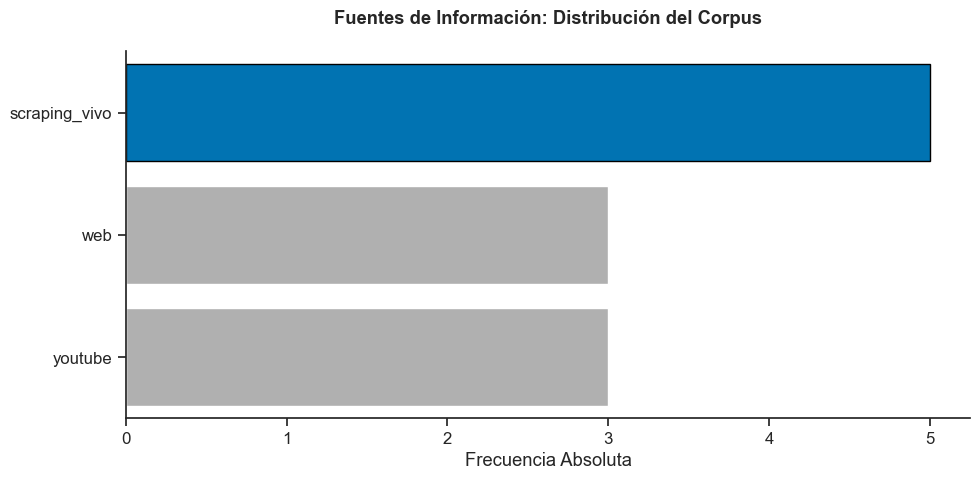

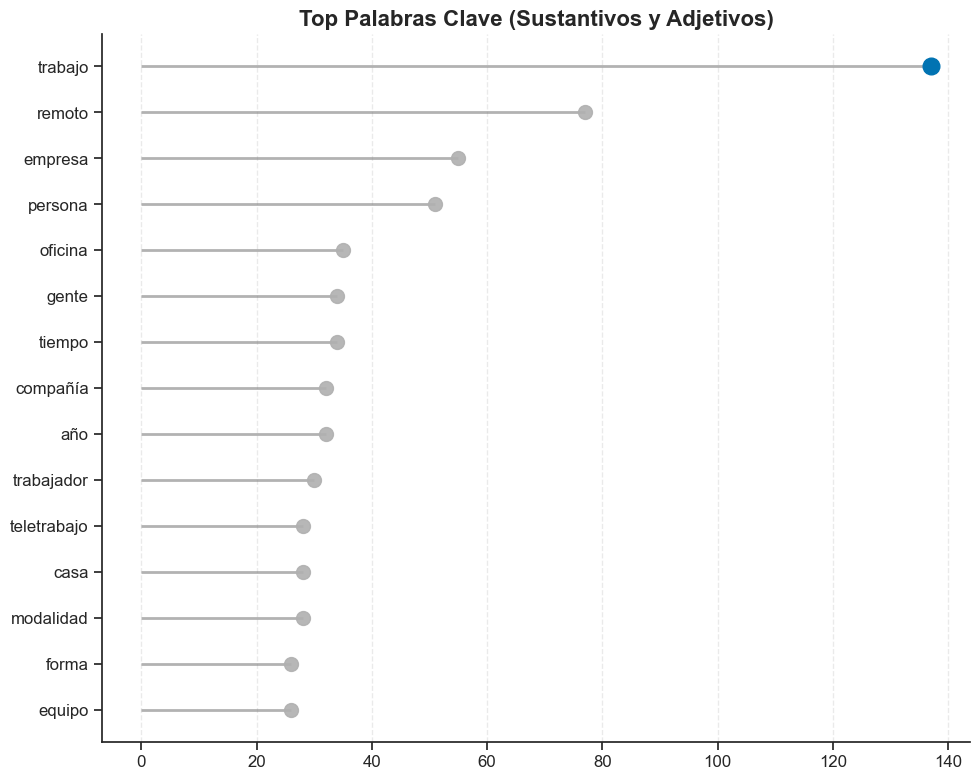

In [58]:
visualizar_origen_accesible(df_final)
analizador = AnalizadorCorpus(df_final, 'texto')

visualizar_palabras_clave_lollipop(analizador.extraer_palabras_clave(15))
visualizar_entidades_plotly(analizador.extraer_entidades())

> **Pausa de auditoría:**
> Revisá tu visualización. ¿Es accesible? El uso de la paleta 'colorblind' asegura que ciertos grados de daltonismo no impidan la lectura cromática, pero ¿el tamaño de fuente y la proporción de la figura se leen correctamente sin forzar la vista? ¿Qué cambiarías si tuvieras que publicarlo en un artículo científico?

**Tamaño de Fuente : En un artículo, el texto del gráfico debe ser similar al tamaño de la fuente del cuerpo del texto (usualmente entre 8pt y 11pt una vez insertado en el PDF).**

**Proporciones y Resolución (DPI):Las revistas científicas exigen alta resolución (mínimo 300 DPI) y formatos vectoriales
Del "Color" al "Contraste y Textura":Incluso la paleta colorblind puede fallar si la revista se imprime en escala de grises**


## Parte 4: Pipeline Integrado (Orquestación)

**Objetivo:** Orquestar los componentes desarrollados en un flujo lógico unificado y persistir los hallazgos en formato estructurado. Todo sistema analítico debe poder guardar su estado final de forma estática.

In [ ]:
class PipelineMediatico:
    def __init__(self, urls_web=None, ruta_json=None, url_audio=None):
        self.urls_web = urls_web
        self.url_audio = url_audio
        self.ruta_json = ruta_json
        self.df = None
        self.analizador = None
        
    def ejecutar_pipeline(self):
        """Orquesta la adquisición, unificación y análisis"""
        # PASO 1: Orquestá las llamadas a las funciones de la Parte 1.
        
        # PASO 2: Instanciá AnalizadorCorpus y derivale el DataFrame resultante para procesar.

        print("Pipeline ejecutado exitosamente.")
        
    def generar_reporte_y_exportar(self, ruta_csv="corpus_resultante.csv", ruta_json="estadisticas.json"):
        """Exporta el dataframe y un JSON analítico"""
        # PASO 3: Persistí self.df como CSV.
        # ¡OJO! La columna 'doc' de spaCy no es serializable, deberías dropearla o extraer sus textos antes de guardar.
        
        # PASO 4: Persistí las estadísticas y el diccionario de entidades devueltas por el Analizador como JSON local.
        pass

# ---- Espacio para pruebas ----
# pipeline = PipelineMediatico(urls_web=["..."], url_audio="...")
# pipeline.ejecutar_pipeline()
# pipeline.generar_reporte_y_exportar()

In [ ]:
pipeline = PipelineMediatico(urls_scraping=urls_scraping, urls_json=urls_json, urls_videos=urls_videos)
pipeline.ejecutar_pipeline()


> **Pausa de auditoría:**
> Imaginá que un equipo de periodismo de datos de tu facultad te pide el corpus procesado. ¿Qué información necesitaban ellos en el CSV plano versus qué preferiste consolidar en el JSON jerárquico? Pensá por qué separamos esas dos naturalezas de exportación y registralo.

## Parte 5: Dashboard Interactivo con Gradio

**Objetivo:** Diseñar una interfaz interactiva que reaccione dinámicamente frente al usuario, conectando el backend analítico con componentes preconstruidos de frontend.

> [!IMPORTANT]
> **Dilema de diseño**
> ¿Qué componentes elegirías para cada salida? Pedile a la IA tres layouts de estructura (por ejemplo: Pestañas vs. Columna vertical vs. Acordeón) para tu dashboard. Elegí el que consideres mejor para la experiencia de lectura evaluativa y descartá explícitamente los otros dos argumentando tu postura técnica.

**Escribí tu justificación acá:**
(*Tu respuesta...*)

In [60]:
# PASO 1: Diseñá el bloque principal de gr.Blocks() interactuando con los métodos de la clase AnalizadorCorpus.
# Sugerencia: Utilizá pestañas (gr.Tab) para separar "Métricas Generales" de "Filtros e Interacción".

with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:
    gr.Markdown("# Explorador de Agenda Mediática")
    
    with gr.Tab("Panorama y Métricas"):
        # Incluí acá la visualización de frecuencias y orígenes, acompañando un gr.DataFrame con métricas generales.
        pass
        
    with gr.Tab("Explorador de Entidades"):
        # Desarrollá un textbox para ingresar una entidad y un botón que dispare
        # un filtrado, mostrando sólo las oraciones dentro de los textos donde se mencionó dicha entidad.
        pass

# Descomentá la siguiente línea cuando el bloque esté terminado
# dashboard_medios.launch()

C:\Users\admin\AppData\Local\Temp\ipykernel_3024\2256453203.py:4: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as dashboard_medios:


---
## Cierre Formal y Checklist de Entrega

1. ¿Corriste el pipeline de principio a fin, comprobando que las funciones se anidan y comparten el DataFrame correctamente?
2. ¿Tu *AI Reflection Log* evidencia que cuestionaste a la IA y al modelo algorítmico, o todas tus celdas dicen "me devolvió un código y lo usé"?
3. ¿Revisaste el impacto visual de los gráficos garantizando que minimizan la "tinta algorítmica" (Data-Ink Ratio)?
4. ¿Justificaste tus decisiones de arquitectura técnica en el código de orquestación y exportación?

Si respondiste positivamente: felicitaciones, completaste el **TPI 1** demostrando un uso constructivo de la IA, asumiendo un rol profesional capaz de dirigir la automatización de forma estratégica e informada.